In [1]:
import sys
print(sys.executable)

/Users/mac/Library/Mobile Documents/com~apple~CloudDocs/Master/MLRG/p14-crew/p14_git/.venv/bin/python


In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, make_scorer
from xgboost import XGBRegressor, plot_importance

# make the repo-root `utils` package importable from this notebook
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "classical_ml" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

from utils.pipeline import SiRNADataPipeline
from utils.splitter import GroupKFoldLeakPerGroup
from utils.merge_historic_data import load_merged_dataset

DATA_DIR = Path("/Users/mac/Library/Mobile Documents/com~apple~CloudDocs/Master/MLRG/p14-crew/dataset")
CMSIRNA_TSV = DATA_DIR / "primary_dataset" / "CMsiRNA_data_update.tsv"
HISTORIC_CSV = DATA_DIR / "Historic_Takayuki_hueskan_ichihara.csv"

OUTPUT_DIR = REPO_ROOT / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

In [3]:
raw_df = load_merged_dataset(str(CMSIRNA_TSV), str(HISTORIC_CSV))
raw_df.shape

loaded 3515 historic rows
merged 43153 CMsiRNA and 3515 historic rows into 46668


(46668, 27)

In [4]:
# clean + encode (usual DataCleaner, no mRNA alignment), flatten to a numeric matrix
pipeline = SiRNADataPipeline(target_len=25)
enriched_df = pipeline.enrich_dataset_with_encodings(raw_df, strict_cleaning=False, add_mrna=False)
X, groups, y = pipeline.prepare_for_classical_ml(enriched_df, target_column="Inhibition")
feature_names = pipeline.build_feature_names(enriched_df) # extract the readable feature names for downstream importance score
assert len(feature_names) == X.shape[1], (len(feature_names), X.shape[1])

# XGBoost handles NaN in X natively; only rows with a missing target are dropped
mask = ~np.isnan(y)
X, groups, y = X[mask], groups[mask], y[mask]
print(X.shape, y.shape, np.unique(groups).size, "genes")
pd.Series(y).describe()

Running qc and data cleaning
dropped 5756 rows (in-vivo 4233, mM 565, conc>200 797, cell 115, inhibition 102)
dropped 1749 rows with NaN concentration
dropped 2198 rows with a missing or >25 nt strand
imputed 6091 missing time rows (median 24.0h at or below 10 nM, 48.0h above)
dropped 6 columns: ['Modification_locations_Sense_strand', 'Modification_locations_Antisense_strand', 'Modifications_sense_strand', 'Modifications_AntiSense_strand_3_5', 'position_Antisense_strand', 'position_Sense_strand']
Dataset successfully enriched
Feature matrix X shape: (36965, 1423), target y shape: (36965,)
(36965, 1423) (36965,) 54 genes


count    36965.00000
mean        42.65613
std         33.91940
min        -99.50000
25%         14.58000
50%         44.67000
75%         71.70000
max        100.00000
dtype: float64

In [5]:
spearman_scorer = make_scorer(lambda yt, yp: spearmanr(yt, yp)[0])

param_dist = {
    "n_estimators": [200, 400, 600, 800],   # number of trees to be built in the boosting model
    "max_depth": [3, 4, 5, 6, 8, 10],   # deeper the tree -> complex the model, higher chance of overfitting
    "learning_rate": [0.01, 0.02, 0.05, 0.1, 0.2],  # step size when updating the weights
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0], # data samples proportion to train each tree
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],  # minimum tree leaf weight; prevents overfitting with a min threshold needed to split a node
    "min_child_weight": [1, 3, 5, 7],
    "reg_lambda": [0.0, 1.0, 5.0, 10.0],
    "reg_alpha": [0.0, 0.1, 1.0, 5.0],
    "gamma": [0.0, 0.1, 0.5, 1.0],  # threshold for making splits on leaf node; higher -> simpler model
}

# CPU multi-core parallelism
def make_model():
    return XGBRegressor(tree_method="hist", n_jobs=-1, random_state=42)

def evaluate(y_true, y_pred):
    return {
        "spearman": spearmanr(y_true, y_pred)[0],
        "pearson": pearsonr(y_true, y_pred)[0],
        "rmse": mean_squared_error(y_true, y_pred) ** 0.5,
        "mae": mean_absolute_error(y_true, y_pred),
    }

def save_pred_plots(y_true, y_pred, tag):
    plt.figure(figsize=(5, 5))
    plt.scatter(y_true, y_pred, s=5, alpha=0.3)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    plt.plot(lims, lims, "r--", lw=1)
    plt.xlabel("Actual inhibition"); plt.ylabel("Predicted inhibition")
    plt.title(f"Predicted vs actual ({tag})")
    plt.tight_layout(); plt.savefig(OUTPUT_DIR / f"pred_vs_actual_{tag}.png", dpi=150); plt.show()

    plt.figure(figsize=(5, 4))
    plt.hist(y_true - y_pred, bins=50)
    plt.xlabel("Residual (actual - predicted)"); plt.ylabel("Count")
    plt.title(f"Residuals ({tag})")
    plt.tight_layout(); plt.savefig(OUTPUT_DIR / f"residuals_{tag}.png", dpi=150); plt.show()

def save_importance_plot(model, tag, max_features=30):
    booster = model.get_booster()
    booster.feature_names = list(feature_names)  # human-readable names instead of f0, f1, ...
    fig, ax = plt.subplots(figsize=(8, 9))
    plot_importance(booster, ax=ax, max_num_features=max_features, importance_type="gain")
    ax.set_title(f"Feature importance ({tag})")
    fig.tight_layout(); fig.savefig(OUTPUT_DIR / f"feature_importance_{tag}.png", dpi=150); plt.show()

# Random hyperparameter search 

## Random split

In [6]:
# random split = optimistic ceiling; tuning runs CV on train only, test stays untouched
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.33, random_state=42)

search_random = RandomizedSearchCV(
    make_model(), param_dist, n_iter=30, scoring=spearman_scorer,
    cv=KFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=-1, random_state=42, verbose=1, refit=True,
)
search_random.fit(X_tr, y_tr)

best_random = search_random.best_estimator_
print("best params:", search_random.best_params_)
print("cv spearman:", search_random.best_score_)

y_pred_random = best_random.predict(X_te)
metrics_random = evaluate(y_te, y_pred_random)
metrics_random

Fitting 3 folds for each of 30 candidates, totalling 90 fits


/Users/mac/Library/Mobile Documents/com~apple~CloudDocs/Master/MLRG/p14-crew/p14_git/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


best params: {'subsample': 0.9, 'reg_lambda': 0.0, 'reg_alpha': 0.0, 'n_estimators': 600, 'min_child_weight': 7, 'max_depth': 8, 'learning_rate': 0.05, 'gamma': 0.0, 'colsample_bytree': 0.7}
cv spearman: 0.808782104116032


{'spearman': np.float64(0.8333023745766727),
 'pearson': np.float64(0.8169667595849971),
 'rmse': 19.634947214593556,
 'mae': 14.621571355971177}

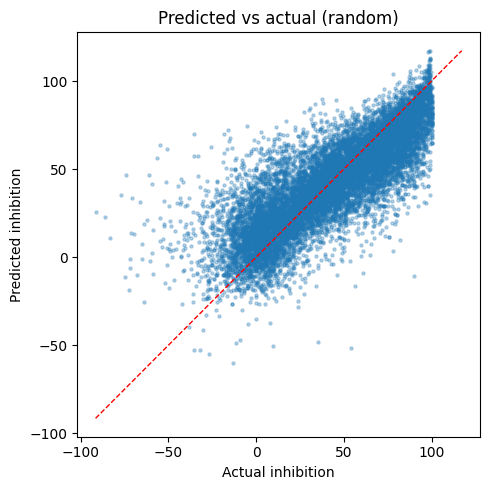

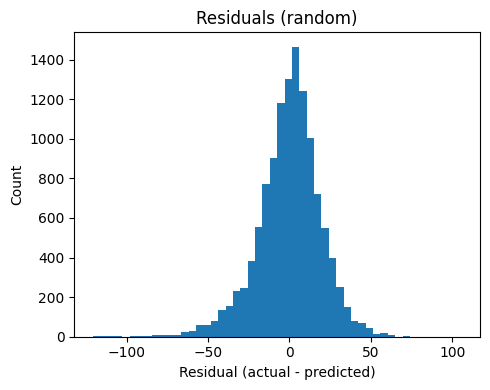

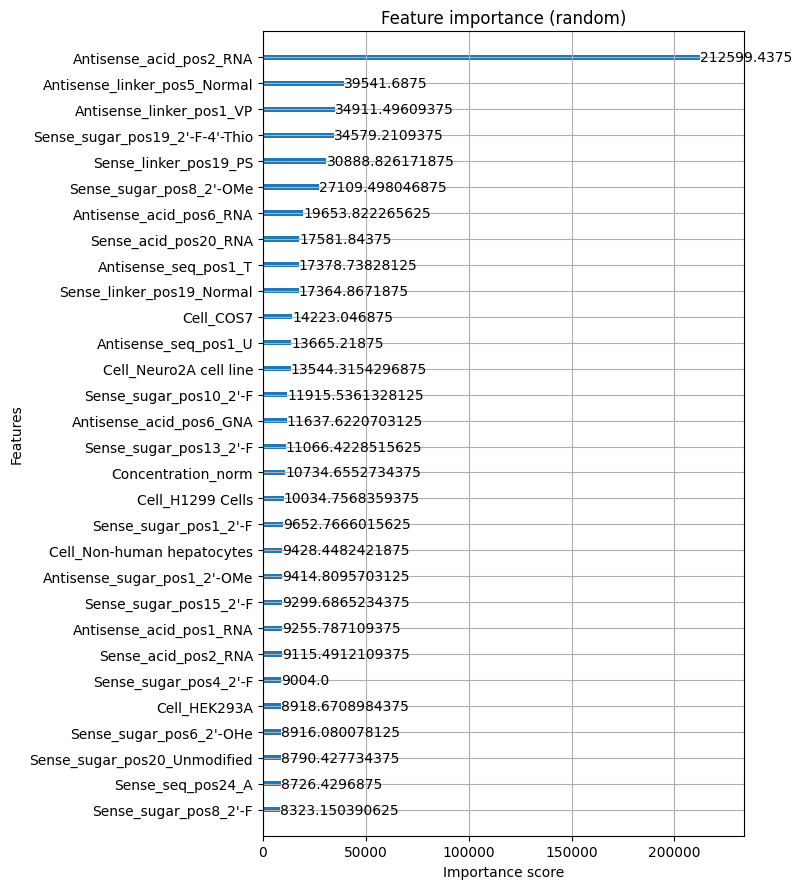

In [7]:
save_pred_plots(y_te, y_pred_random, "random")
save_importance_plot(best_random, "random")

## By-gene splitting Random Search

In [8]:
# by-gene split = realistic generalization to unseen targets; CV folds are whole genes
gene_cv = GroupKFoldLeakPerGroup(n_splits=3, leak_n=30, random_state=42)

# for each of 3 folds, model trains on 'train' genes, evaluated on held-out gene
# spearman is calculated on the pooled held-out predictions
search_gene = RandomizedSearchCV(
    make_model(), param_dist, n_iter=30, scoring=spearman_scorer,
    cv=gene_cv, n_jobs=-1, random_state=42, verbose=1, refit=True,
)
search_gene.fit(X, y, groups=groups)

best_gene = search_gene.best_estimator_
print("best params:", search_gene.best_params_)
print("cv spearman (across genes):", search_gene.best_score_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


/Users/mac/Library/Mobile Documents/com~apple~CloudDocs/Master/MLRG/p14-crew/p14_git/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


best params: {'subsample': 0.6, 'reg_lambda': 10.0, 'reg_alpha': 5.0, 'n_estimators': 800, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 0.6}
cv spearman (across genes): 0.4956689685122475


In [9]:
# out-of-fold predictions: refit best params per fold and collect held-out genes
oof_true, oof_pred = [], []
for tr_idx, te_idx in gene_cv.split(X, y, groups):
    model = make_model().set_params(**search_gene.best_params_)
    model.fit(X[tr_idx], y[tr_idx]) 
    oof_true.append(y[te_idx])
    oof_pred.append(model.predict(X[te_idx]))

# each cv fold predicts only on its held-out rows; concatenating across folds -> every 
# row has a prediction from the model that never saw it during training
y_true_gene = np.concatenate(oof_true)
y_pred_gene = np.concatenate(oof_pred)
metrics_gene = evaluate(y_true_gene, y_pred_gene)
metrics_gene

{'spearman': np.float64(0.4186833981741333),
 'pearson': np.float64(0.41599669773189996),
 'rmse': 32.14292114628977,
 'mae': 25.054083447136765}

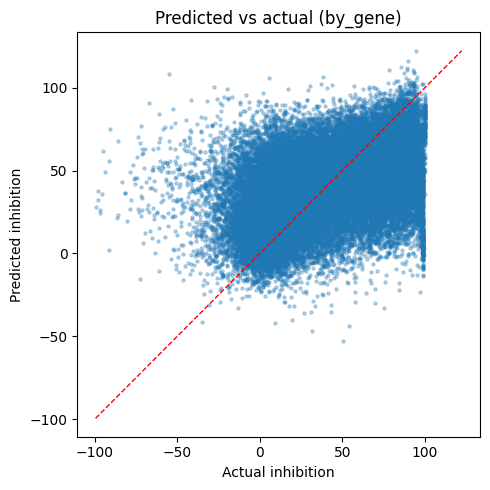

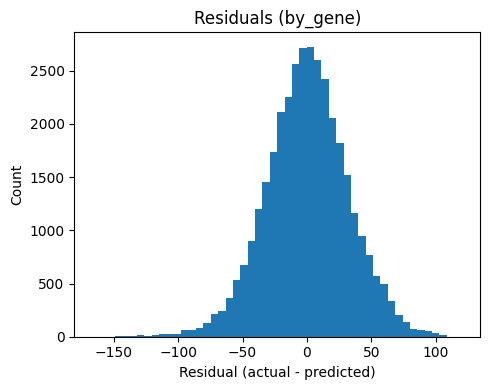

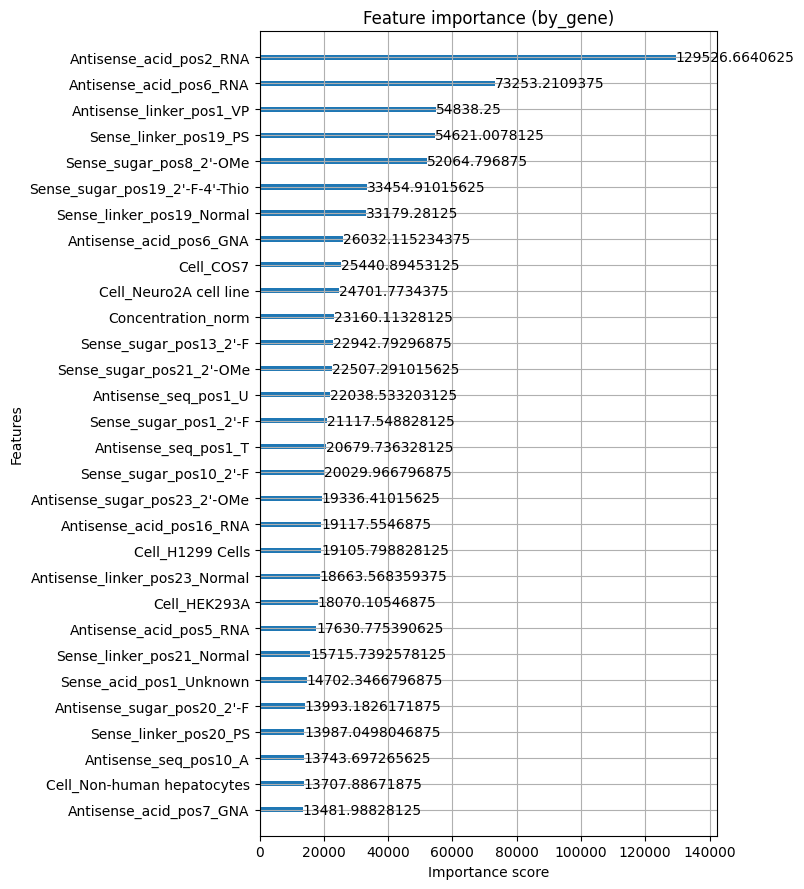

In [10]:
save_pred_plots(y_true_gene, y_pred_gene, "by_gene")

# gain - average improvement in the loss reduction, contributed by all splits using given feature
# higher gain -> feature made splits that reduced error the most; how much it shrinked the squared error sum
save_importance_plot(best_gene, "by_gene")

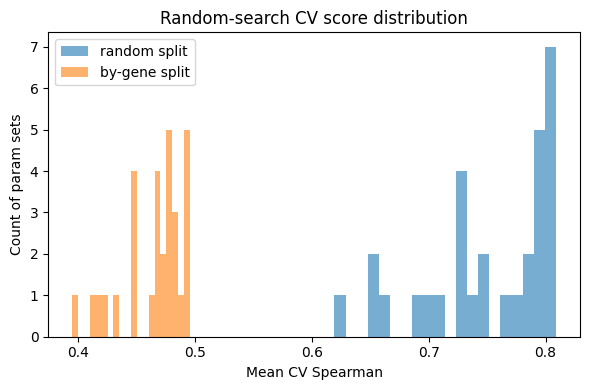

,spearman,pearson,rmse,mae
random_split,0.833302,0.816967,19.634947,14.621571
by_gene_split,0.418683,0.415997,32.142921,25.054083


In [11]:
plt.figure(figsize=(6, 4))
plt.hist(search_random.cv_results_["mean_test_score"], bins=20, alpha=0.6, label="random split")
plt.hist(search_gene.cv_results_["mean_test_score"], bins=20, alpha=0.6, label="by-gene split")
plt.xlabel("Mean CV Spearman"); plt.ylabel("Count of param sets"); plt.legend()
plt.title("Random-search CV score distribution")
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "cv_score_distribution.png", dpi=150); plt.show()

summary = pd.DataFrame({"random_split": metrics_random, "by_gene_split": metrics_gene}).T
summary.to_csv(OUTPUT_DIR / "metrics_summary.csv")
summary

# Optuna tuning 

https://optuna.org/#code_examples

Inspiration taken from the following kaggle notebook: https://www.kaggle.com/code/cahyaalkahfi/xgboost-model-tuning-using-optuna.

## Optuna tuning on the gene split, seeded with the randomized-search winner

In [12]:
import optuna
import optuna.visualization as vis
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

# Optuna tuning on the by-gene split, seeded with the by-gene randomized-search winner
def objective_gene(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800, step=100),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 7),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 10.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
        "gamma": trial.suggest_float("gamma", 0.0, 1.0),
    }
    model = make_model().set_params(**params)
    return cross_val_score(model, X, y, groups=groups, scoring=spearman_scorer, cv=gene_cv).mean()

study_gene = optuna.create_study(direction="maximize")
study_gene.enqueue_trial(search_gene.best_params_)  # first trial = by-gene randomized-search best
study_gene.optimize(objective_gene, n_trials=40, n_jobs=1, show_progress_bar=True)

best_params_gene_nomrna = study_gene.best_params  # reused to seed the mRNA by-gene study
print("best cv spearman (across genes):", study_gene.best_value)
print("best params:", study_gene.best_params)

  0%|          | 0/40 [00:00<?, ?it/s]

best cv spearman (across genes): 0.5047439714990173
best params: {'n_estimators': 600, 'max_depth': 4, 'learning_rate': 0.05039699016295945, 'subsample': 0.6877416962774061, 'colsample_bytree': 0.9865522246918672, 'min_child_weight': 4, 'reg_lambda': 0.5725742285872766, 'reg_alpha': 3.101578138736836, 'gamma': 0.08789625018726158}


In [13]:
# out-of-fold predictions with the optuna best params, plus a full-data fit for importance
oof_true_g, oof_pred_g = [], []
for tr_idx, te_idx in gene_cv.split(X, y, groups):
    model = make_model().set_params(**study_gene.best_params)
    model.fit(X[tr_idx], y[tr_idx])
    oof_true_g.append(y[te_idx])
    oof_pred_g.append(model.predict(X[te_idx]))

y_true_gene_optuna = np.concatenate(oof_true_g)
y_pred_gene_optuna = np.concatenate(oof_pred_g)
metrics_gene_optuna = evaluate(y_true_gene_optuna, y_pred_gene_optuna)
metrics_gene_optuna_nomrna = metrics_gene_optuna  # kept for the no-mRNA vs mRNA comparison

best_gene_optuna = make_model().set_params(**study_gene.best_params)
best_gene_optuna.fit(X, y)
metrics_gene_optuna

{'spearman': np.float64(0.4075561999397586),
 'pearson': np.float64(0.40920651295414),
 'rmse': 32.031284793121436,
 'mae': 25.122376429908083}

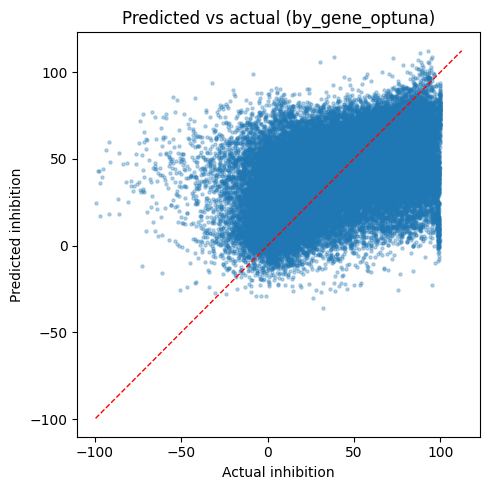

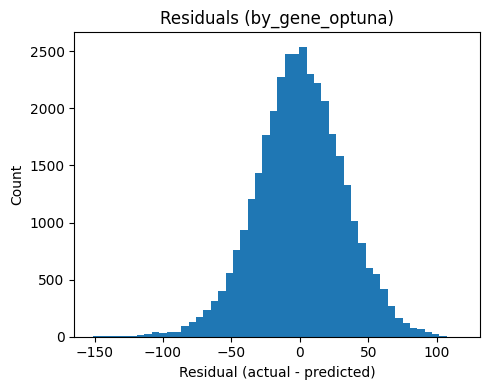

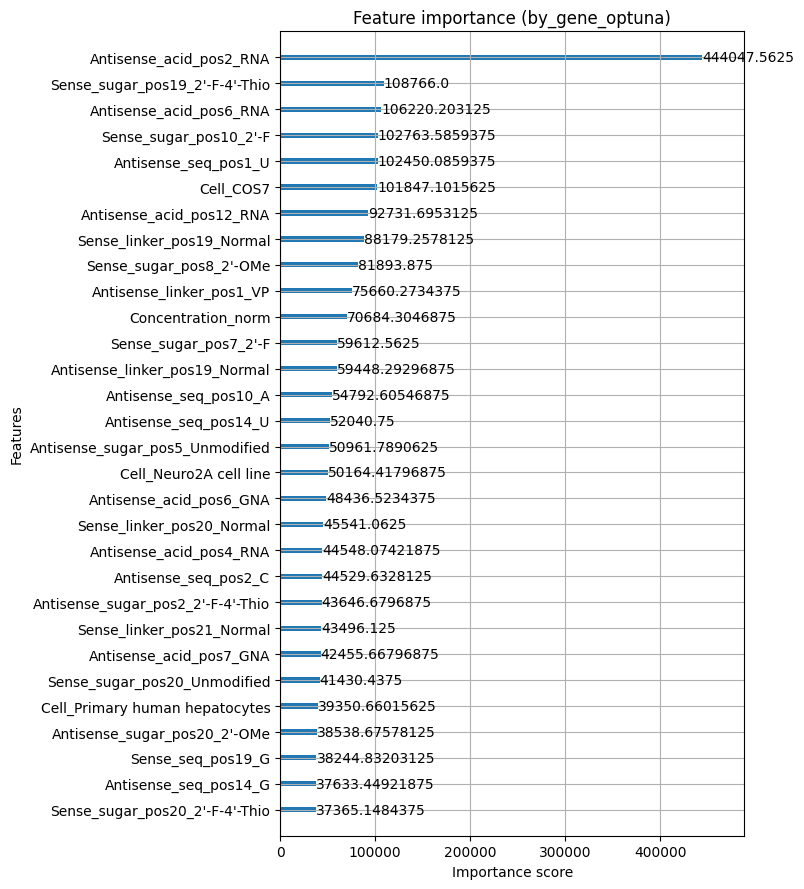

,spearman,pearson,rmse,mae
by_gene_random_search,0.418683,0.415997,32.142921,25.054083
by_gene_optuna,0.407556,0.409207,32.031285,25.122376


In [14]:
save_pred_plots(y_true_gene_optuna, y_pred_gene_optuna, "by_gene_optuna")
save_importance_plot(best_gene_optuna, "by_gene_optuna")

pd.DataFrame({"by_gene_random_search": metrics_gene, "by_gene_optuna": metrics_gene_optuna}).T

In [15]:
display(vis.plot_param_importances(study_gene))
display(vis.plot_optimization_history(study_gene))

## Optuna on random split seeded with randomized search winner

In [16]:
tuning_cv = KFold(n_splits=3, shuffle=True, random_state=42)

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800, step=100),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 7),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 10.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
        "gamma": trial.suggest_float("gamma", 0.0, 1.0),
    }
    model = make_model().set_params(**params)
    return cross_val_score(model, X_tr, y_tr, scoring=spearman_scorer, cv=tuning_cv).mean()

study = optuna.create_study(direction="maximize")
study.enqueue_trial(search_random.best_params_)  # first trial = randomized-search best
study.optimize(objective, n_trials=40, n_jobs=1, show_progress_bar=True)

best_params_random_nomrna = study.best_params  # reused to seed the mRNA random-split study
print("best cv spearman:", study.best_value)
print("best params:", study.best_params)

  0%|          | 0/40 [00:00<?, ?it/s]

best cv spearman: 0.808782104116032
best params: {'n_estimators': 600, 'max_depth': 8, 'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.7, 'min_child_weight': 7, 'reg_lambda': 0.0, 'reg_alpha': 0.0, 'gamma': 0.0}


In [17]:
best_optuna = make_model().set_params(**study.best_params)
best_optuna.fit(X_tr, y_tr)

y_pred_optuna = best_optuna.predict(X_te)
metrics_optuna = evaluate(y_te, y_pred_optuna)
metrics_optuna_nomrna = metrics_optuna  # kept for the no-mRNA vs mRNA comparison
metrics_optuna

{'spearman': np.float64(0.8333023745766727),
 'pearson': np.float64(0.8169667595849971),
 'rmse': 19.634947214593556,
 'mae': 14.621571355971177}

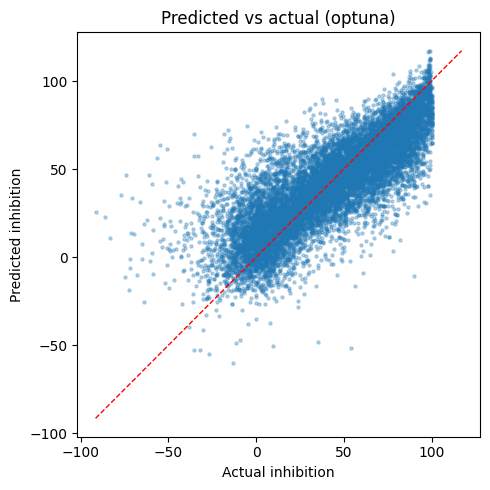

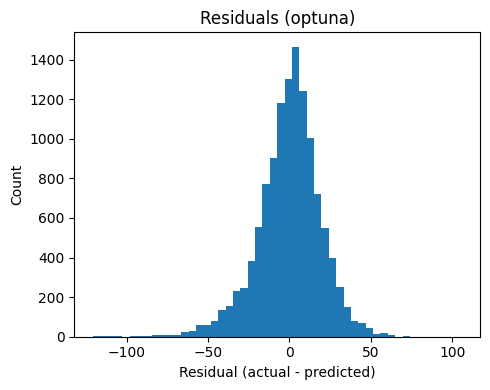

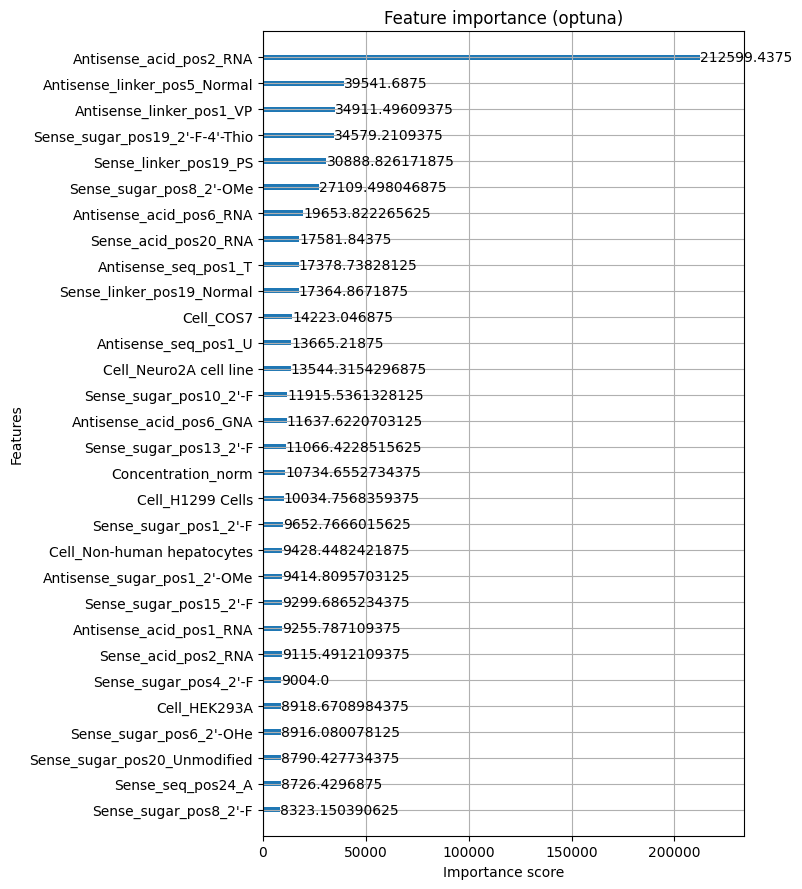

,spearman,pearson,rmse,mae
random_search,0.833302,0.816967,19.634947,14.621571
optuna,0.833302,0.816967,19.634947,14.621571


In [18]:
save_pred_plots(y_te, y_pred_optuna, "optuna")
save_importance_plot(best_optuna, "optuna")

pd.DataFrame({"random_search": metrics_random, "optuna": metrics_optuna}).T

In [19]:
display(vis.plot_param_importances(study))
display(vis.plot_optimization_history(study))

# With mRNA sequences

In [20]:
enriched_df_mrna = pipeline.enrich_dataset_with_encodings(raw_df, strict_cleaning=False, add_mrna=True)
X, groups, y = pipeline.prepare_for_classical_ml(enriched_df_mrna, target_column="Inhibition")
feature_names = pipeline.build_feature_names(enriched_df_mrna)  # mRNA frame so names include edit_distance and target_site_pct
assert len(feature_names) == X.shape[1], (len(feature_names), X.shape[1])

mask = ~np.isnan(y)
X, groups, y = X[mask], groups[mask], y[mask]

Running qc and data cleaning
dropped 5756 rows (in-vivo 4233, mM 565, conc>200 797, cell 115, inhibition 102)
dropped 1749 rows with NaN concentration
dropped 2198 rows with a missing or >25 nt strand
imputed 6091 missing time rows (median 24.0h at or below 10 nM, 48.0h above)
dropped 6 columns: ['Modification_locations_Sense_strand', 'Modification_locations_Antisense_strand', 'Modifications_sense_strand', 'Modifications_AntiSense_strand_3_5', 'position_Antisense_strand', 'position_Sense_strand']
Mapping mRNA structural profiles
Error reading reference dataset: [Errno 2] No such file or directory: '/home/larsena8/software/fennec/src/fennec/support_files/train_data_v1.1.0_N=27742.csv'
Loaded 13 gene sequences from local cache
Loaded 0 gene sequences from reference CSV
Building gene -> mRNA mapping for 54 genes...
[1/54] Processing CTNNB1...
  Found in local cache (3074 bp)
[2/54] Processing INHBE...
  Found in local cache (2460 bp)
[3/54] Processing LPA...
  Found in local cache (6431 b

## Random split

In [21]:
# re-split on the mRNA feature matrix (the cell-6 split was the no-mRNA X)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.33, random_state=42)
tuning_cv = KFold(n_splits=3, shuffle=True, random_state=42)

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800, step=100),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 7),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 10.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
        "gamma": trial.suggest_float("gamma", 0.0, 1.0),
    }
    model = make_model().set_params(**params)
    return cross_val_score(model, X_tr, y_tr, scoring=spearman_scorer, cv=tuning_cv).mean()

study = optuna.create_study(direction="maximize")
study.enqueue_trial(best_params_random_nomrna)  # first trial = no-mRNA optuna best
study.optimize(objective, n_trials=40, n_jobs=1, show_progress_bar=True)

print("best cv spearman:", study.best_value)
print("best params:", study.best_params)

  0%|          | 0/40 [00:00<?, ?it/s]

best cv spearman: 0.8412629890209145
best params: {'n_estimators': 700, 'max_depth': 9, 'learning_rate': 0.05644252612276648, 'subsample': 0.9908560353238086, 'colsample_bytree': 0.8341322370847281, 'min_child_weight': 7, 'reg_lambda': 5.683229059379634, 'reg_alpha': 4.3323727615796335, 'gamma': 0.6436988616639515}


In [22]:
best_optuna = make_model().set_params(**study.best_params)
best_optuna.fit(X_tr, y_tr)

y_pred_optuna = best_optuna.predict(X_te)
metrics_optuna = evaluate(y_te, y_pred_optuna)
metrics_optuna

{'spearman': np.float64(0.8612770118628147),
 'pearson': np.float64(0.8486774837859503),
 'rmse': 18.005283953647947,
 'mae': 13.28508864493651}

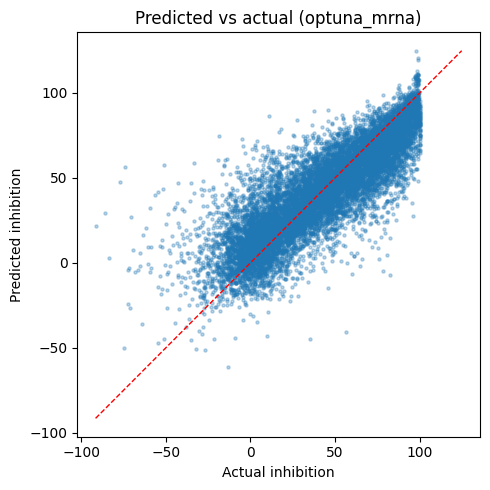

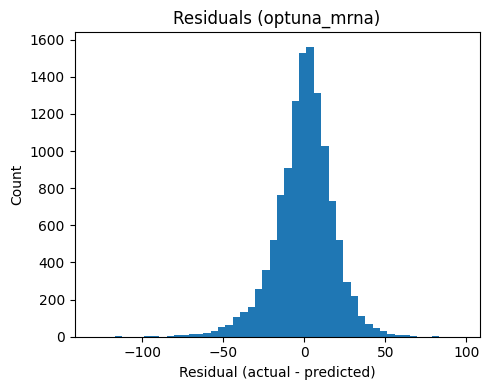

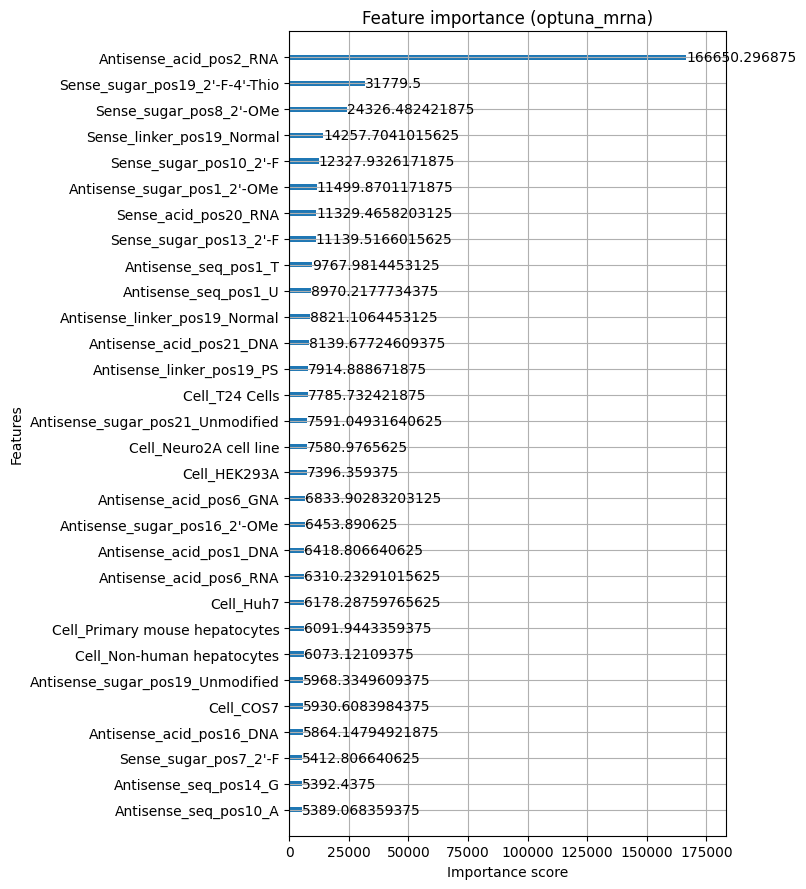

,spearman,pearson,rmse,mae
no_mrna_optuna,0.833302,0.816967,19.634947,14.621571
mrna_optuna,0.861277,0.848677,18.005284,13.285089


In [23]:
save_pred_plots(y_te, y_pred_optuna, "optuna_mrna")
save_importance_plot(best_optuna, "optuna_mrna")

pd.DataFrame({"no_mrna_optuna": metrics_optuna_nomrna, "mrna_optuna": metrics_optuna}).T

In [24]:
display(vis.plot_param_importances(study))
display(vis.plot_optimization_history(study))

## By-gene splitting strategy

In [25]:
# Optuna tuning on the by-gene split, seeded with the by-gene randomized-search winner
def objective_gene(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800, step=100),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 7),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 10.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
        "gamma": trial.suggest_float("gamma", 0.0, 1.0),
    }
    model = make_model().set_params(**params)
    return cross_val_score(model, X, y, groups=groups, scoring=spearman_scorer, cv=gene_cv).mean()

study_gene = optuna.create_study(direction="maximize")
study_gene.enqueue_trial(best_params_gene_nomrna)  # first trial = no-mRNA by-gene optuna best
study_gene.optimize(objective_gene, n_trials=40, n_jobs=1, show_progress_bar=True)

print("best cv spearman (across genes):", study_gene.best_value)
print("best params:", study_gene.best_params)

  0%|          | 0/40 [00:00<?, ?it/s]

best cv spearman (across genes): 0.5277334867018014
best params: {'n_estimators': 800, 'max_depth': 4, 'learning_rate': 0.15881823130907038, 'subsample': 0.8812898741586134, 'colsample_bytree': 0.7824379872752019, 'min_child_weight': 4, 'reg_lambda': 0.8342807691178866, 'reg_alpha': 1.4296995092035882, 'gamma': 0.07531958697602548}


In [26]:
# honest cross-gene predictions with the optuna best params, plus a full-data fit for importance
oof_true_g, oof_pred_g = [], []
for tr_idx, te_idx in gene_cv.split(X, y, groups):
    model = make_model().set_params(**study_gene.best_params)
    model.fit(X[tr_idx], y[tr_idx])
    oof_true_g.append(y[te_idx])
    oof_pred_g.append(model.predict(X[te_idx]))

y_true_gene_optuna = np.concatenate(oof_true_g)
y_pred_gene_optuna = np.concatenate(oof_pred_g)
metrics_gene_optuna = evaluate(y_true_gene_optuna, y_pred_gene_optuna)

best_gene_optuna = make_model().set_params(**study_gene.best_params)
best_gene_optuna.fit(X, y)
metrics_gene_optuna

{'spearman': np.float64(0.46111485713083133),
 'pearson': np.float64(0.4558760866325805),
 'rmse': 31.564631804029865,
 'mae': 24.60836992260443}

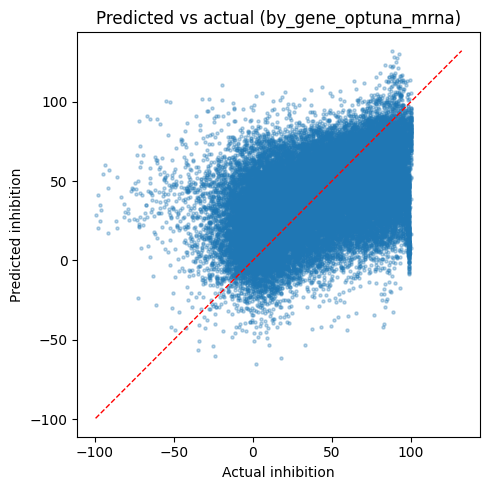

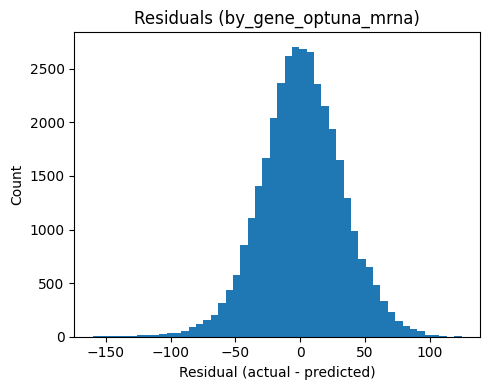

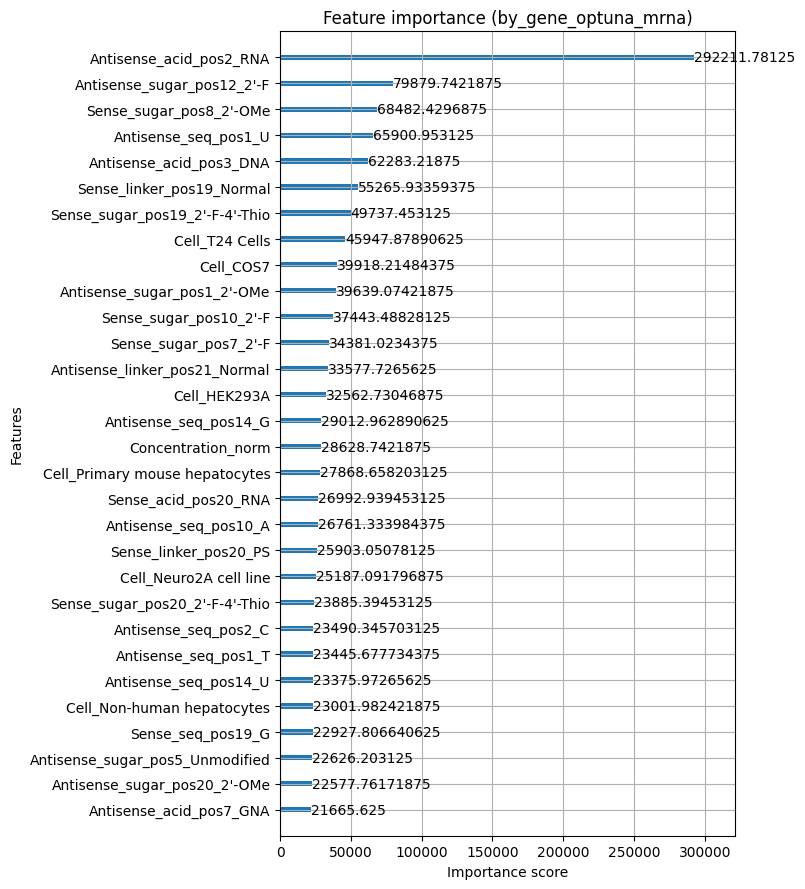

,spearman,pearson,rmse,mae
by_gene_no_mrna,0.407556,0.409207,32.031285,25.122376
by_gene_mrna,0.461115,0.455876,31.564632,24.608370


In [27]:
save_pred_plots(y_true_gene_optuna, y_pred_gene_optuna, "by_gene_optuna_mrna")
save_importance_plot(best_gene_optuna, "by_gene_optuna_mrna")

pd.DataFrame({"by_gene_no_mrna": metrics_gene_optuna_nomrna, "by_gene_mrna": metrics_gene_optuna}).T

In [28]:
display(vis.plot_param_importances(study_gene))
display(vis.plot_optimization_history(study_gene))